In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

DATA_DIR = Path("p2_data")

def face_key(path):
    person, shot = path.stem.split("_")
    return int(person), int(shot)

def read_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float64)

all_paths = sorted(DATA_DIR.glob("*.png"), key=face_key)
train_paths = [p for p in all_paths if face_key(p)[1] <= 9]
test_paths = [p for p in all_paths if face_key(p)[1] == 10]

sample = read_gray(train_paths[0])
image_shape = sample.shape
X_train = np.vstack([read_gray(p).reshape(1, -1) for p in train_paths])
X_test = np.vstack([read_gray(p).reshape(1, -1) for p in test_paths])
y_train = np.array([face_key(p)[0] for p in train_paths])
y_test = np.array([face_key(p)[0] for p in test_paths])

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Image shape:", image_shape)


Training images: (360, 2576)
Testing images: (40, 2576)
Image shape: (56, 46)


# Problem: Principal Component Analysis

Perform PCA on a face image dataset, visualize eigenfaces, reconstruct an image with different numbers of components, and evaluate KNN face recognition.


In [2]:
pca = PCA(n_components=345, svd_solver="randomized", random_state=0)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

def normalize_image(img):
    img = np.asarray(img, dtype=np.float64)
    return (img - img.min()) / (img.max() - img.min() + 1e-12)

print("PCA score shape:", X_train_pca.shape)
print("Explained variance retained by 345 components:", pca.explained_variance_ratio_.sum())


PCA score shape: (360, 345)
Explained variance retained by 345 components: 0.9993925878429903


## 1. Mean face and first four eigenfaces


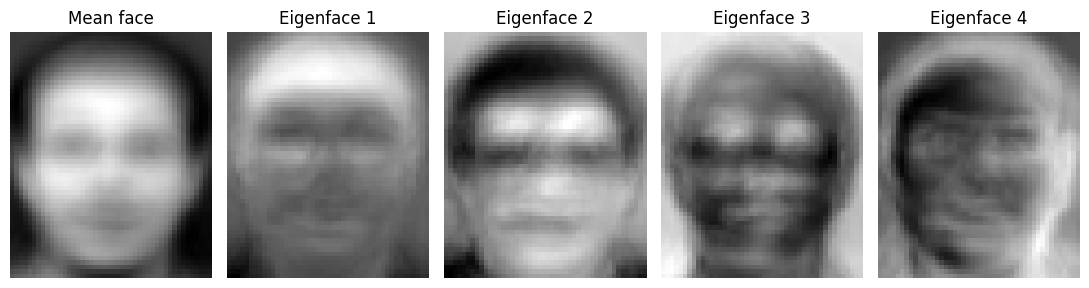

In [3]:
mean_face = pca.mean_.reshape(image_shape)
eigenfaces = pca.components_[:4].reshape((4,) + image_shape)

fig, axes = plt.subplots(1, 5, figsize=(11, 3))
axes[0].imshow(mean_face, cmap="gray")
axes[0].set_title("Mean face")
axes[0].axis("off")

for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(normalize_image(eigenfaces[i - 1]), cmap="gray")
    ax.set_title(f"Eigenface {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. Reconstruct person 2 image 1 using n = 3, 50, 170, 240, 345 eigenfaces
## 3. Compute the mean squared error


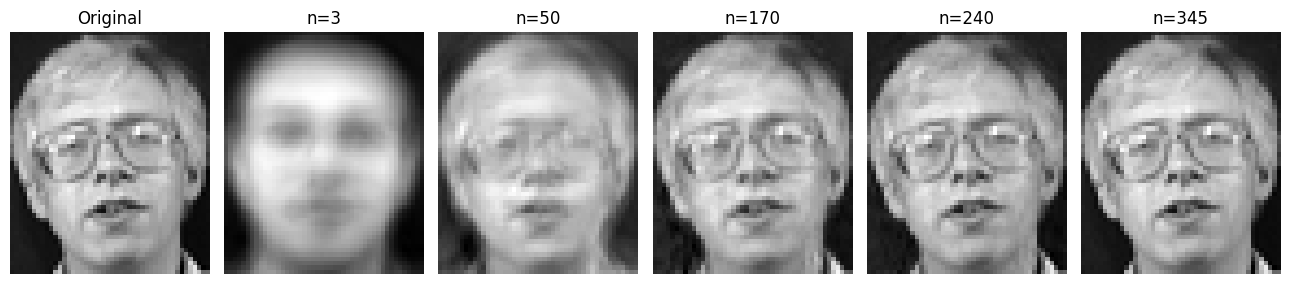

,n_components,mse
0,3,746.799408
1,50,236.554309
2,170,46.717034
3,240,13.366986
4,345,0.208962


In [4]:
probe_path = DATA_DIR / "2_1.png"
probe = read_gray(probe_path).reshape(1, -1)
probe_scores = pca.transform(probe)
component_counts = [3, 50, 170, 240, 345]

fig, axes = plt.subplots(1, len(component_counts) + 1, figsize=(13, 3))
axes[0].imshow(probe.reshape(image_shape), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

mse_rows = []
for ax, n in zip(axes[1:], component_counts):
    reconstructed = pca.mean_ + probe_scores[:, :n] @ pca.components_[:n]
    mse = np.mean((probe - reconstructed) ** 2)
    mse_rows.append({"n_components": n, "mse": mse})
    ax.imshow(np.clip(reconstructed.reshape(image_shape), 0, 255), cmap="gray")
    ax.set_title(f"n={n}")
    ax.axis("off")

plt.tight_layout()
plt.show()

mse_table = pd.DataFrame(mse_rows)
mse_table


## 4. Cross-validation results


In [5]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
rows = []
for k in [1, 3, 5]:
    for n in [3, 50, 170]:
        clf = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(clf, X_train_pca[:, :n], y_train, cv=cv)
        rows.append({
            "k": k,
            "n_components": n,
            "mean_accuracy": scores.mean(),
            "std_accuracy": scores.std(),
        })

cv_results = pd.DataFrame(rows)
cv_results


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe6 in position 18: illegal multibyte sequence


C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,n_components,mean_accuracy,std_accuracy
0,1,3,0.730556,0.038690
1,1,50,0.980556,0.017123
2,1,170,0.977778,0.007857
3,3,3,0.666667,0.011785
4,3,50,0.938889,0.003928
5,3,170,0.941667,0.006804
6,5,3,0.588889,0.014164
7,5,50,0.888889,0.017123
8,5,170,0.877778,0.023895


## 5. Recognition rate of the testing set


In [6]:
def recognition_rate(k, n):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_pca[:, :n], y_train)
    return clf.score(X_test_pca[:, :n], y_test)

k = 1
n = 140
test_accuracy = recognition_rate(k, n)
print(f"Recognition rate (k={k}, n={n}): {test_accuracy:.4f}")

all_test_results = []
for k in [1, 3, 5]:
    for n in [3, 50, 140, 170, 240, 345]:
        all_test_results.append({
            "k": k,
            "n_components": n,
            "test_accuracy": recognition_rate(k, n),
        })

pd.DataFrame(all_test_results).sort_values("test_accuracy", ascending=False)


Recognition rate (k=1, n=140): 0.9500


,k,n_components,test_accuracy
3,1,170,0.950
2,1,140,0.950
11,3,345,0.925
1,1,50,0.925
4,1,240,0.925
5,1,345,0.925
17,5,345,0.900
7,3,50,0.900
16,5,240,0.900
8,3,140,0.900
